In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
print(" Libraries loaded")


ModuleNotFoundError: No module named 'matplotlib'

## 1. Load Data

In [3]:
df = pd.read_csv("train.csv")
print(f"Shape: {df.shape}")
df.head(3)


Shape: (439140, 16)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
print("Null values:")
print(df.isnull().sum())
print(f"\nTarget distribution:")
print(df['PitNextLap'].value_counts(normalize=True).round(3))


Null values:
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Target distribution:
PitNextLap
0.0    0.801
1.0    0.199
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

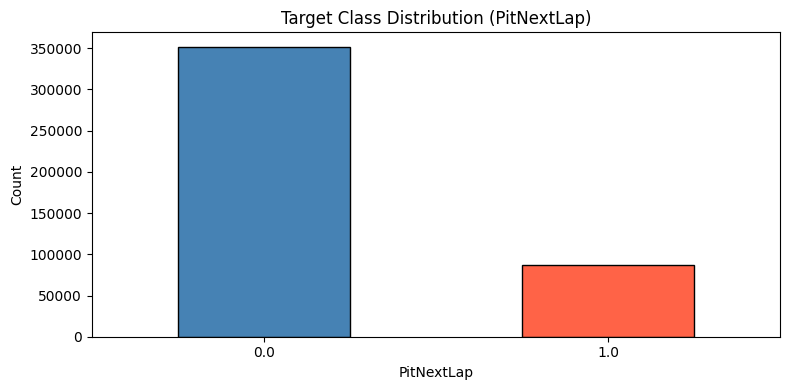

In [6]:
plt.figure(figsize=(8, 4))
df['PitNextLap'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Target Class Distribution (PitNextLap)')
plt.xlabel('PitNextLap'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


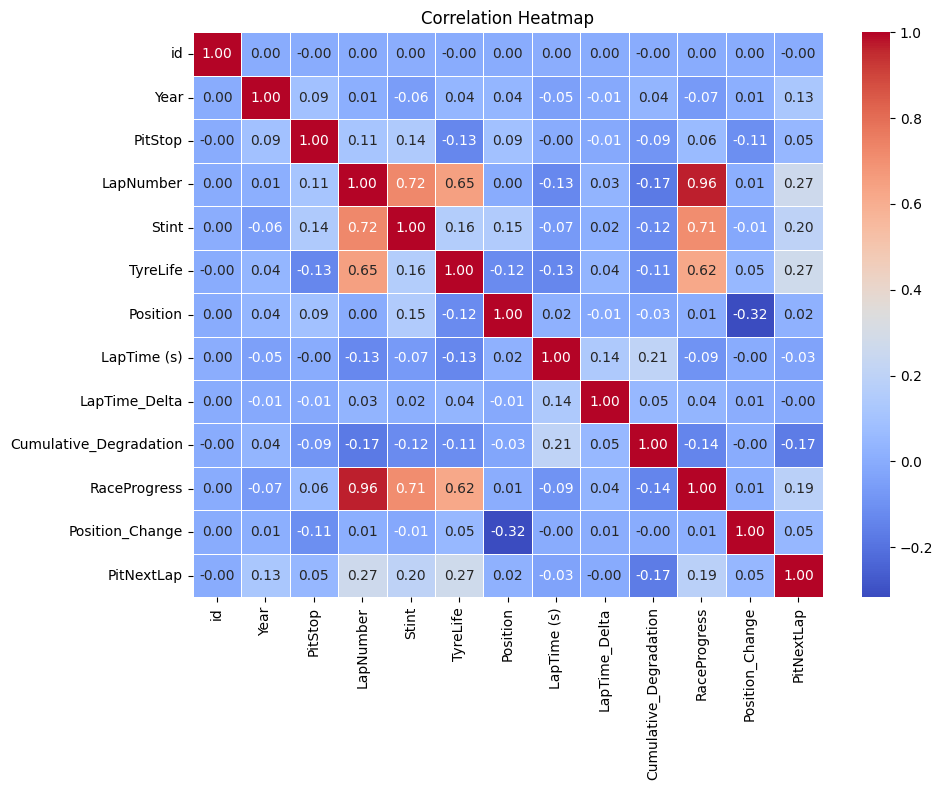

Correlation with PitNextLap:
PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
id                       -0.000097
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64


In [7]:
# Keep numeric columns for correlation (including LapTime_Delta & LapNumber — check before dropping!)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
matrix = df[num_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()

# Check correlation of LapTime_Delta and LapNumber with target
print("Correlation with PitNextLap:")
print(matrix['PitNextLap'].sort_values(ascending=False))


> **Note:** Only drop `LapTime_Delta` and `LapNumber` if they show near-zero or data-leakage correlation.
> Keep them if they're predictive — we'll let the model decide via feature importance.


## 3. Preprocessing

In [8]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
print("Categorical columns:", cat_col)

for col in cat_col:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))


Categorical columns: ['Driver', 'Compound', 'Race']

Driver: 887 unique values
Driver
MAS    1682
RAI    1669
BAR    1656
BUT    1655
FIS    1651
Name: count, dtype: int64

Compound: 5 unique values
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64

Race: 26 unique values
Race
Dutch Grand Prix          24462
Mexico City Grand Prix    23672
Pre-Season Testing        22492
Hungarian Grand Prix      22481
Monaco Grand Prix         21539
Name: count, dtype: int64


In [9]:
# ── Label Encode high-cardinality columns ──
label_encoders = {}
for col in ['Driver', 'Race']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le   # save for test preprocessing
    print(f"Label-encoded: {col}")

# ── One-Hot Encode low-cardinality columns ──
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = ohe.fit_transform(df[['Compound']].astype(str))
encoded_df = pd.DataFrame(encoded_data,
                           columns=ohe.get_feature_names_out(['Compound']),
                           index=df.index)
df = pd.concat([df, encoded_df], axis=1).drop(columns=['Compound'])
print("One-hot encoded: Compound")
print(f"\nFinal shape after encoding: {df.shape}")


Label-encoded: Driver
Label-encoded: Race
One-hot encoded: Compound

Final shape after encoding: (439140, 20)


In [10]:
# Drop columns that were shown to be non-predictive or data-leaky
# (re-check correlation above before uncommenting)
# df = df.drop(['LapTime_Delta', 'LapNumber'], axis=1)

train_id = df['id']
X = df.drop(['id', 'PitNextLap'], axis=1)
y = df['PitNextLap']

# Scale ONLY on train data; save scaler for test
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Class balance in train: {y_train.value_counts(normalize=True).round(3).to_dict()}")


X_train: (351312, 18), X_val: (87828, 18)
Class balance in train: {0.0: 0.801, 1.0: 0.199}


## 4. Baseline Models (with Cross-Validation)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "XGBClassifier": XGBClassifier(use_label_encoder=False,
                                   eval_metric='logloss',
                                   random_state=SEED,
                                   n_estimators=300),
    "CatBoostClassifier": CatBoostClassifier(verbose=False,
                                              iterations=500,
                                              random_state=SEED)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name}: CV ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")


XGBClassifier: CV ROC-AUC = 0.9464 ± 0.0009
CatBoostClassifier: CV ROC-AUC = 0.9465 ± 0.0007


## 5. Hyperparameter Tuning (Optuna — CatBoost)

In [ ]:
best_params = study.best_params
best_params['verbose'] = False
best_params['random_state'] = SEED

best_model = CatBoostClassifier(**best_params)
best_model.fit(X_train, y_train,
               eval_set=(X_val, y_val),
               early_stopping_rounds=50)

# Evaluate
y_val_pred = best_model.predict_proba(X_val)[:, 1]
val_roc = roc_auc_score(y_val, y_val_pred)
print(f"\n✅ Validation ROC-AUC (hold-out): {val_roc:.4f}")


## 6. Feature Importance

In [ ]:
feat_names = X.columns.tolist()
importances = best_model.get_feature_importance()

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (CatBoost)')
plt.tight_layout(); plt.show()


## 7. Save Model & Preprocessors

In [ ]:
# Save everything needed for test-time preprocessing
joblib.dump(best_model,      'trained_catboost_model.pkl')
joblib.dump(scaler,          'scaler.pkl')
joblib.dump(ohe,             'ohe_compound.pkl')
joblib.dump(label_encoders,  'label_encoders.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("✅ Saved: trained_catboost_model.pkl")
print("✅ Saved: scaler.pkl")
print("✅ Saved: ohe_compound.pkl")
print("✅ Saved: label_encoders.pkl")
print("✅ Saved: feature_columns.pkl")
print(f"\nFinal Validation ROC-AUC: {val_roc:.4f}")
